# Full pipeline execution code

## Multimodal Retrieval Pipeline (Image + Caption Embedding with Milvus)

### **Overall Workflow**
1. **Image Captioning** → Generate descriptive captions using **Florence-2-base**  
2. **Embedding Generation**  
   - **Image Embedding:** `CLIP-ViT-B-32`  
   - **Caption Embedding:** `all-MiniLM-L6-v2`  
3. **Vector Storage** → Store both embeddings in **Milvus**  
4. **Re-ranking** → Combine retrieval results using weighted similarity (Late Fusion)

1. **Image Captioning**
- Florence-2-base

In [ ]:
# !pip install --no-cache-dir einops timm
#!pip install -r requirements.txt --upgrade

In [ ]:
# import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [1]:
import sys
sys.path.append("/Users/kimsejung/Model/5.milvus/milvus_clip_llm_rag")

In [3]:
from captioning.captioning import FlorenceCaptioner

if __name__ == "__main__":
    captioner = FlorenceCaptioner()
    captioner.load_model()

    # you can dynamically define your prompt
    prompt = "<DETAILED_CAPTION>"

    captioner.generate_captions(
        image_folder="./images_folder/train",
        output_csv="./caption.csv",
        prompt=prompt
    )

Using device: mps
Loading microsoft/Florence-2-base...
✅ Model loaded successfully on [mps]
1005 images → start captioning


Captioning: 100%|███████████████████████████| 1005/1005 [10:54<00:00,  1.54it/s]


✅ Completed! 1005 captions saved → ./caption.csv


2. **Embedding Generation**
   - **Image Embedding:** `CLIP-ViT-B-32`  
   - **Caption Embedding:** `all-MiniLM-L6-v2`

In [3]:
from pymilvus import MilvusClient, DataType
from embedding.encoder import ImageTextEmbedder

# Milvus 연결
client = MilvusClient(uri="http://localhost:19530")

# 컬렉션 이름
collection_name = "florence_clip_miniLM"

# 기존 컬렉션 삭제 (원할 때만 주석 해제)
# if client.has_collection(collection_name):
#     client.drop_collection(collection_name)
#     print(f" Dropped existing collection: {collection_name}")

# 스키마 생성
schema = client.create_schema(auto_id=False, enable_dynamic_field=True)

# 필드 정의 (ImageTextEmbedder 구조에 맞게)
schema.add_field("id", DataType.INT64, is_primary=True)
schema.add_field("vector_clip_image", DataType.FLOAT_VECTOR, dim=512)   # CLIP 이미지 임베딩
schema.add_field("vector_clip_text", DataType.FLOAT_VECTOR, dim=384)    # MiniLM 텍스트 임베딩
schema.add_field("caption", DataType.VARCHAR, max_length=1000)          # 캡션 텍스트
schema.add_field("filepath", DataType.VARCHAR, max_length=512)          # 이미지 경로
schema.add_field("metadata", DataType.VARCHAR, max_length=512)          # 메타데이터 (옵션)
schema.add_field("created_at", DataType.VARCHAR, max_length=32)         # 생성 시간 (옵션)

# 인덱스 파라미터 설정
index_params = client.prepare_index_params()
index_params.add_index(
    field_name="vector_clip_image",
    index_type="IVF_FLAT",
    metric_type="IP",
    params={"nlist": 128}
)
index_params.add_index(
    field_name="vector_clip_text",
    index_type="IVF_FLAT",
    metric_type="IP",
    params={"nlist": 128}
)

# 컬렉션 생성
client.create_collection(
    collection_name=collection_name,
    schema=schema,
    index_params=index_params
)

print(f" Created collection for ImageTextEmbedder: {collection_name}")


 Created collection for ImageTextEmbedder: florence_clip_miniLM


In [7]:
from datetime import datetime
import json, os
import pandas as pd
from tqdm import tqdm

from embedding.encoder import ImageTextEmbedder


csv_path = "./caption.csv"   # FlorenceCaptioner가 생성한 CSV 파일
collection_name = "florence_clip_miniLM"

data_to_insert = []
id_counter = 1


# ImageTextEmbedder 클래스 인스턴스 생성 (임베딩 전용)

encoder = ImageTextEmbedder()  # 모델 로드됨 (CLIP + MiniLM)

# caption.csv 파일 로드

df = pd.read_csv(csv_path)
print(f" Loaded {len(df)} captions from {csv_path}")


# CSV의 image_path + caption 기반으로 임베딩 생성

for _, row in tqdm(df.iterrows(), total=len(df), desc="Embedding captions"):
    path = row["image_path"]
    caption = row["caption"]
    created_time = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")

    # 이미지 임베딩 (512차원)
    img_vec = encoder._embed_image(path)

    # 캡션 텍스트 임베딩 (384차원)
    text_vec = encoder._embed_text(caption)

    if img_vec is None or text_vec is None:
        continue

    data_to_insert.append({
        "id": id_counter,
        "vector_clip_image": img_vec.tolist(),
        "vector_clip_text": text_vec.tolist(),
        "caption": caption,
        "filepath": path,
        "metadata": json.dumps({"source": "caption_csv"}),
        "created_at": created_time
    })
    id_counter += 1


# Milvus에 삽입

client.insert(collection_name=collection_name, data=data_to_insert)
print(f" Inserted {len(data_to_insert)} caption-based entries into '{collection_name}'")


 Using device: cpu
 Loading embedding models...
 Models loaded successfully.
 Loaded 1005 captions from ./caption.csv


Embedding captions: 100%|███████████████████| 1005/1005 [00:35<00:00, 28.04it/s]

 Inserted 1005 caption-based entries into 'florence_clip_miniLM'


3. **chatbot 생성**
- LangChain RAG 생성
- "사람이 등장하는 이미지는 총 몇장이지? 그리고 해당하는 이미지 1개만 보여줘"

In [19]:
import os

env_path = ".env"

if not os.path.exists(env_path):
    key = input(" Enter your OpenAI API Key (starts with sk-): ").strip()
    with open(env_path, "w") as f:
        f.write(f"OPENAI_API_KEY={key}\n")
    print(f" .env file created successfully at {os.path.abspath(env_path)}")
else:
    print(" .env file already exists!")

 .env file already exists!


- llm으로 넘기는 문서를 제안하지 않을 경우 토큰 한도 초과

/opt/anaconda3/envs/florence/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



LLM Response:
 총 18장의 이미지 중 사람이 등장하는 이미지는 17장입니다. 그중 하나의 파일 경로는 다음과 같습니다:

Filepath: images_folder/train/jean/n03594734_24159.JPEG

 Showing image: images_folder/train/jean/n03594734_24159.JPEG


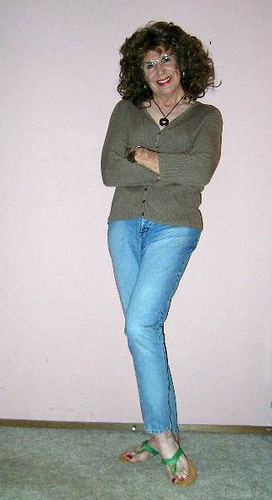

In [1]:
from langchain.langchain_rag import FlorenceRAG

florence_rag = FlorenceRAG()
rag_chain = florence_rag.build_rag_chain()

query = "사람이 등장하는 이미지는 총 몇 장이지? 그리고 그중 하나를 보여줘."

response = rag_chain.invoke(query)
print("\nLLM Response:\n", response)

florence_rag.show_image_from_response(response)